In [22]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pyreadr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn import set_config

# Configuración de visualización
set_config(display='diagram')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

SEED = 123
np.random.seed(SEED)

In [23]:
# Ajustar la ruta al archivo según corresponda
RUTA_DATOS = 'listings.RData'

resultado = pyreadr.read_r(RUTA_DATOS)
df = resultado['listings']

print(f"Dimensiones originales: {df.shape}")
print(f"Cantidad de variables: {df.shape[1]}")
df.head()

Dimensiones originales: (171748, 80)
Cantidad de variables: 80


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [24]:
# Ver los tipos de variables
print("Distribución de tipos de datos:")
print(df.dtypes.value_counts())
# Distribución por ciudad
print("\nListings por ciudad:")
print(df['city'].value_counts())

Distribución de tipos de datos:
object     47
int32      18
float64    15
Name: count, dtype: int64

Listings por ciudad:
city
Los Angeles, California      45585
New York, New York           36261
Hawaii                       33457
San Diego, California        13162
Austin, Texas                10533
Chicago, Illinois             8660
San Francisco, California     7535
Washington, D.C.              6374
Rhode Island                  5762
Boston, Massachusetts         4419
Name: count, dtype: int64


In [25]:
df['price_num'] = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

print("Estadísticas de price_num:")
print(df['price_num'].describe())
print(f"\nNulos en price: {df['price_num'].isna().sum()} "
      f"({df['price_num'].isna().mean()*100:.1f}%)")

Estadísticas de price_num:
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price_num, dtype: float64

Nulos en price: 95502 (55.6%)


In [26]:
# Nulos de precio por ciudad
print("Porcentaje de precios nulos por ciudad:")
nulos_ciudad = df.groupby('city')['price_num'].apply(
    lambda x: x.isna().mean()*100
).sort_values(ascending=False)
print(nulos_ciudad.round(2))

Porcentaje de precios nulos por ciudad:
city
Los Angeles, California      100.00
New York, New York           100.00
San Francisco, California    100.00
Washington, D.C.              23.25
Boston, Massachusetts         20.66
San Diego, California         13.53
Rhode Island                  13.35
Chicago, Illinois              9.64
Hawaii                         0.97
Austin, Texas                  0.15
Name: price_num, dtype: float64


In [27]:
# Filtrar registros con precio válido
df = df[df['price_num'].notna()].copy()
print(f"Dimensiones tras filtrar nulos de precio: {df.shape}")

Dimensiones tras filtrar nulos de precio: (76246, 81)


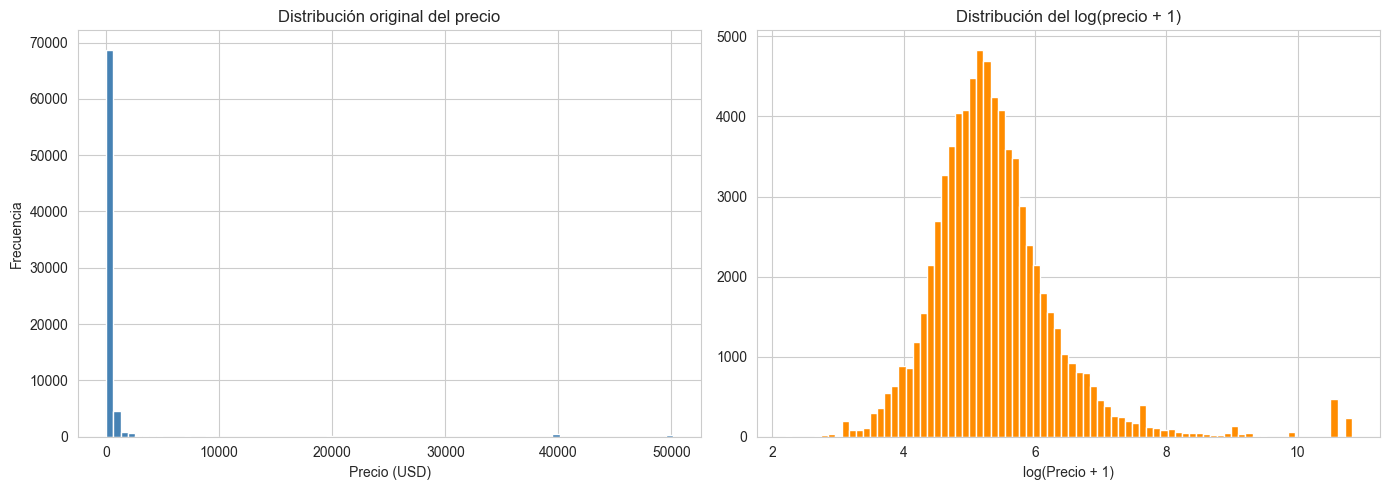

Skewness original: 9.87


In [28]:
## Distribución de precios por ciudad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price_num'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución original del precio')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df['price_num']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución del log(precio + 1)')
axes[1].set_xlabel('log(Precio + 1)')
plt.tight_layout()
plt.show()

print(f"Skewness original: {df['price_num'].skew():.2f}")

In [29]:
p99 = np.percentile(df['price_num'], 99)
print(f"P99 del precio: ${p99:.2f}")
df = df[df['price_num'] <= p99].copy()
print(f"Dimensiones después de filtrar outliers: {df.shape}")

P99 del precio: $20000.00
Dimensiones después de filtrar outliers: (75531, 81)


Punto de corte P33: $140.00
Punto de corte P66: $260.00

Distribución de la variable categórica:
price_cat
cara      25628
media     24968
barata    24935
Name: count, dtype: int64


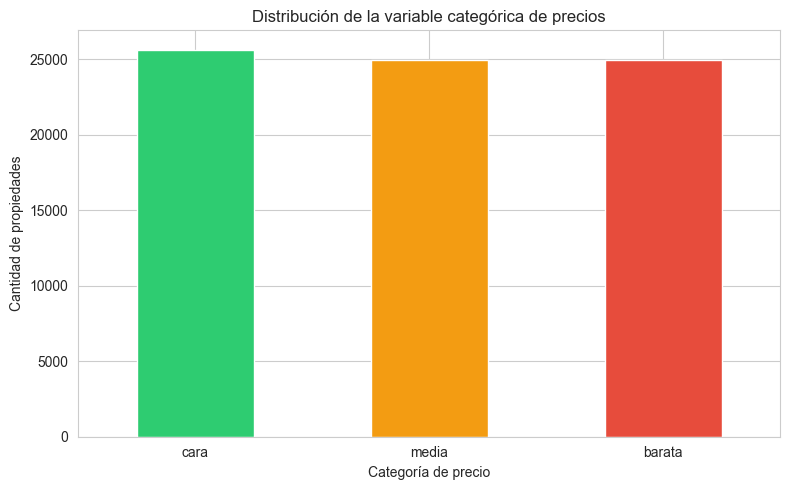

In [30]:
p33 = np.percentile(df['price_num'], 33)
p66 = np.percentile(df['price_num'], 66)
print(f"Punto de corte P33: ${p33:.2f}")
print(f"Punto de corte P66: ${p66:.2f}")

df['price_cat'] = pd.cut(
    df['price_num'],
    bins=[-np.inf, p33, p66, np.inf],
    labels=['barata', 'media', 'cara']
)

print("\nDistribución de la variable categórica:")
print(df['price_cat'].value_counts())

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
df['price_cat'].value_counts().plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'], ax=ax)
ax.set_title('Distribución de la variable categórica de precios')
ax.set_xlabel('Categoría de precio')
ax.set_ylabel('Cantidad de propiedades')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
for col in ['bedrooms', 'beds', 'host_listings_count', 'host_total_listings_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [32]:
# Variables numéricas seleccionadas
nombre_numericas = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'calculated_host_listings_count',
    'latitude', 'longitude',
]

# Variables categóricas seleccionadas
nombre_categoricas = [
    'room_type', 'host_is_superhost',
    'host_identity_verified', 'instant_bookable', 'city',
]

variables_modelo = nombre_numericas + nombre_categoricas
print(f"Total de variables predictoras: {len(variables_modelo)}")
print(f"  - Numéricas: {len(nombre_numericas)}")
print(f"  - Categóricas: {len(nombre_categoricas)}")

Total de variables predictoras: 25
  - Numéricas: 20
  - Categóricas: 5


In [33]:
data = df[variables_modelo].copy()
target = df['price_cat'].copy()

# Reemplazar strings vacíos en categóricas
for col in nombre_categoricas:
    data[col] = data[col].replace('', np.nan)
    data[col] = data[col].fillna('desconocido')

print(f"Dimensiones de data: {data.shape}")
print(f"Dimensiones de target: {target.shape}")
print(f"\nNulos por variable numérica:")
print(data[nombre_numericas].isna().sum())

Dimensiones de data: (75531, 25)
Dimensiones de target: (75531,)

Nulos por variable numérica:
accommodates                          0
bathrooms                            14
bedrooms                            121
beds                                 80
minimum_nights                        0
maximum_nights                        0
availability_30                       0
availability_60                       0
availability_90                       0
availability_365                      0
number_of_reviews                     0
number_of_reviews_ltm                 0
review_scores_rating              12867
review_scores_cleanliness         12871
review_scores_location            12871
review_scores_value               12871
reviews_per_month                 12867
calculated_host_listings_count        0
latitude                              0
longitude                             0
dtype: int64


In [34]:
TAMANIO_MUESTRA = 8000

data_sample, _, target_sample, _ = train_test_split(
    data, target,
    train_size=TAMANIO_MUESTRA,
    stratify=target,
    random_state=SEED
)

print(f"Tamaño de la muestra: {len(data_sample)}")
print("Distribución de clases en la muestra:")
print(target_sample.value_counts(normalize=True).round(3))

Tamaño de la muestra: 8000
Distribución de clases en la muestra:
price_cat
cara      0.339
media     0.331
barata    0.330
Name: proportion, dtype: float64


In [35]:
data_train, data_test, target_train, target_test = train_test_split(
    data_sample, target_sample,
    test_size=0.3,
    train_size=0.7,
    stratify=target_sample,
    random_state=SEED
)

print(f"Conjunto de entrenamiento: {data_train.shape}")
print(f"Conjunto de prueba: {data_test.shape}")
print("\nDistribución en train:")
print(target_train.value_counts(normalize=True).round(3))
print("\nDistribución en test:")
print(target_test.value_counts(normalize=True).round(3))

Conjunto de entrenamiento: (5600, 25)
Conjunto de prueba: (2400, 25)

Distribución en train:
price_cat
cara      0.339
media     0.331
barata    0.330
Name: proportion, dtype: float64

Distribución en test:
price_cat
cara      0.339
media     0.331
barata    0.330
Name: proportion, dtype: float64


In [36]:
preprocesador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

preprocesador_categorico = OneHotEncoder(handle_unknown='ignore')

preprocesador = ColumnTransformer([
    ('num', preprocesador_numerico, nombre_numericas),
    ('cat', preprocesador_categorico, nombre_categoricas),
], remainder='drop')

preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [37]:
modelo_lineal = make_pipeline(preprocesador, SVC(kernel='linear', random_state=SEED))

t0 = time.time()
modelo_lineal.fit(data_train, target_train)
tiempo_lineal = time.time() - t0
print(f"Tiempo de entrenamiento (lineal): {tiempo_lineal:.2f} s")

pred_train_lineal = modelo_lineal.predict(data_train)
pred_test_lineal = modelo_lineal.predict(data_test)

acc_train_lineal = accuracy_score(target_train, pred_train_lineal)
acc_test_lineal = accuracy_score(target_test, pred_test_lineal)
print(f"Accuracy en train: {acc_train_lineal:.4f}")
print(f"Accuracy en test : {acc_test_lineal:.4f}")

Tiempo de entrenamiento (lineal): 0.95 s
Accuracy en train: 0.6641
Accuracy en test : 0.6521


In [38]:
modelo_poly = make_pipeline(preprocesador, SVC(kernel='poly', degree=3, random_state=SEED))

t0 = time.time()
modelo_poly.fit(data_train, target_train)
tiempo_poly = time.time() - t0
print(f"Tiempo de entrenamiento (polinomial): {tiempo_poly:.2f} s")

pred_train_poly = modelo_poly.predict(data_train)
pred_test_poly = modelo_poly.predict(data_test)

acc_train_poly = accuracy_score(target_train, pred_train_poly)
acc_test_poly = accuracy_score(target_test, pred_test_poly)
print(f"Accuracy en train: {acc_train_poly:.4f}")
print(f"Accuracy en test : {acc_test_poly:.4f}")

Tiempo de entrenamiento (polinomial): 0.57 s
Accuracy en train: 0.7330
Accuracy en test : 0.6579


In [39]:
modelo_rbf = make_pipeline(preprocesador, SVC(kernel='rbf', random_state=SEED))

t0 = time.time()
modelo_rbf.fit(data_train, target_train)
tiempo_rbf = time.time() - t0
print(f"Tiempo de entrenamiento (RBF): {tiempo_rbf:.2f} s")

pred_train_rbf = modelo_rbf.predict(data_train)
pred_test_rbf = modelo_rbf.predict(data_test)

acc_train_rbf = accuracy_score(target_train, pred_train_rbf)
acc_test_rbf = accuracy_score(target_test, pred_test_rbf)
print(f"Accuracy en train: {acc_train_rbf:.4f}")
print(f"Accuracy en test : {acc_test_rbf:.4f}")

Tiempo de entrenamiento (RBF): 0.57 s
Accuracy en train: 0.7320
Accuracy en test : 0.6637


In [40]:
param_grid_lineal = {
    'svc__C': [0.01, 0.1, 1, 10],
}

modelo_lineal_base = make_pipeline(preprocesador, SVC(kernel='linear', random_state=SEED))

t0 = time.time()
grid_lineal = GridSearchCV(
    modelo_lineal_base, param_grid=param_grid_lineal,
    cv=5, n_jobs=-1, scoring='accuracy'
)
grid_lineal.fit(data_train, target_train)
tiempo_grid_lineal = time.time() - t0

print(f"Tiempo de tuneo (lineal): {tiempo_grid_lineal:.2f} s")
print(f"Mejores parámetros: {grid_lineal.best_params_}")
print(f"Mejor accuracy CV: {grid_lineal.best_score_:.4f}")
print(f"Accuracy en test : {grid_lineal.score(data_test, target_test):.4f}")

Tiempo de tuneo (lineal): 8.35 s
Mejores parámetros: {'svc__C': 10}
Mejor accuracy CV: 0.6539
Accuracy en test : 0.6517


In [41]:
param_grid_poly = {
    'svc__C': [0.1, 1, 10],
    'svc__degree': [2, 3, 4],
    'svc__gamma': ['scale', 'auto'],
}

modelo_poly_base = make_pipeline(preprocesador, SVC(kernel='poly', random_state=SEED))

t0 = time.time()
grid_poly = GridSearchCV(
    modelo_poly_base, param_grid=param_grid_poly,
    cv=5, n_jobs=-1, scoring='accuracy'
)
grid_poly.fit(data_train, target_train)
tiempo_grid_poly = time.time() - t0

print(f"Tiempo de tuneo (polinomial): {tiempo_grid_poly:.2f} s")
print(f"Mejores parámetros: {grid_poly.best_params_}")
print(f"Mejor accuracy CV: {grid_poly.best_score_:.4f}")
print(f"Accuracy en test : {grid_poly.score(data_test, target_test):.4f}")


Tiempo de tuneo (polinomial): 8.34 s
Mejores parámetros: {'svc__C': 10, 'svc__degree': 2, 'svc__gamma': 'scale'}
Mejor accuracy CV: 0.6736
Accuracy en test : 0.6683


In [42]:
param_grid_rbf = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 'scale'],
}

modelo_rbf_base = make_pipeline(preprocesador, SVC(kernel='rbf', random_state=SEED))

t0 = time.time()
grid_rbf = GridSearchCV(
    modelo_rbf_base, param_grid=param_grid_rbf,
    cv=5, n_jobs=-1, scoring='accuracy'
)
grid_rbf.fit(data_train, target_train)
tiempo_grid_rbf = time.time() - t0

print(f"Tiempo de tuneo (RBF): {tiempo_grid_rbf:.2f} s")
print(f"Mejores parámetros: {grid_rbf.best_params_}")
print(f"Mejor accuracy CV: {grid_rbf.best_score_:.4f}")
print(f"Accuracy en test : {grid_rbf.score(data_test, target_test):.4f}")


Tiempo de tuneo (RBF): 10.55 s
Mejores parámetros: {'svc__C': 10, 'svc__gamma': 'scale'}
Mejor accuracy CV: 0.6764
Accuracy en test : 0.6687


In [43]:
cv_results_rbf = pd.DataFrame(grid_rbf.cv_results_)[
    ['param_svc__C', 'param_svc__gamma','mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10)
cv_results_rbf


,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,rank_test_score
11,10.0,scale,0.676429,0.009952,1
13,100.0,0.01,0.676250,0.011880,2
9,10.0,0.01,0.674107,0.009600,3
6,1.0,0.1,0.673929,0.007521,4
7,1.0,scale,0.673750,0.009872,5
12,100.0,0.001,0.669821,0.008249,6
10,10.0,0.1,0.658571,0.016284,7
5,1.0,0.01,0.655893,0.007547,8
8,10.0,0.001,0.647321,0.012963,9
14,100.0,0.1,0.638929,0.012860,10


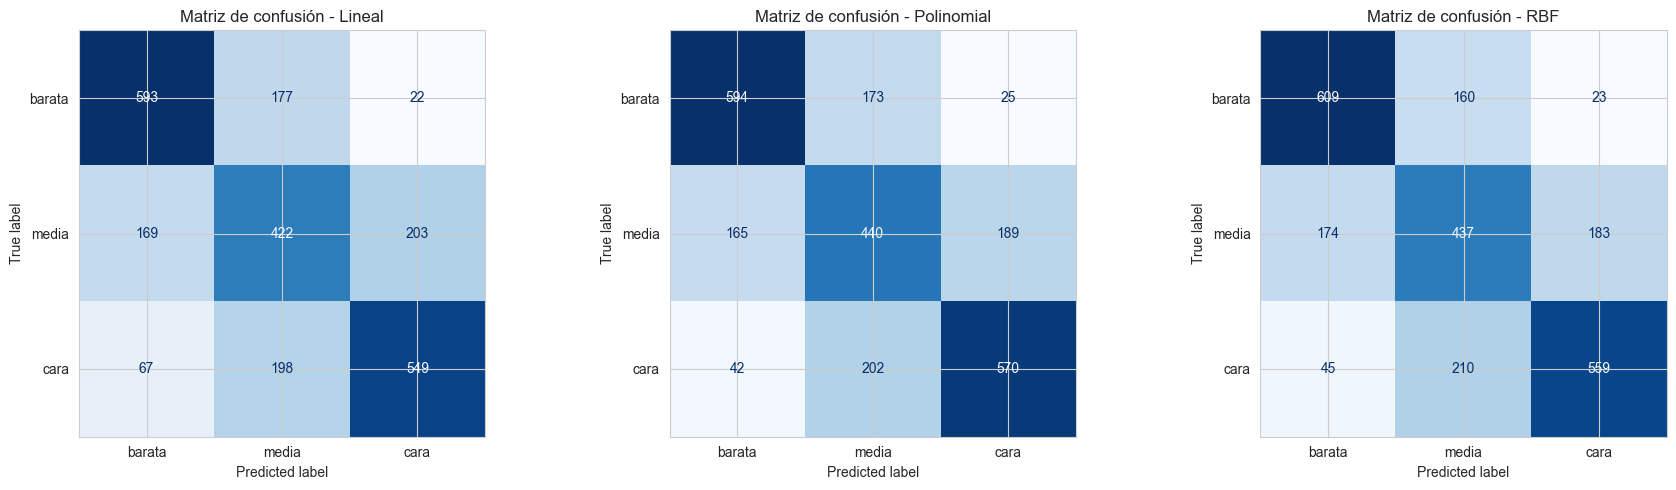

In [45]:
mejores_modelos = {
    'Lineal': grid_lineal.best_estimator_,
    'Polinomial': grid_poly.best_estimator_,
    'RBF': grid_rbf.best_estimator_,
}

# Predicciones
predicciones = {nombre: m.predict(data_test) for nombre, m in mejores_modelos.items()}

# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
clases = ['barata', 'media', 'cara']
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(target_test, pred, labels=clases)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de confusión - {nombre}')
plt.tight_layout()
plt.show()


In [46]:
for nombre, pred in predicciones.items():
 print(f"\n{'='*60}")
 print(f"REPORTE DE CLASIFICACIÓN - Kernel {nombre}")
 print('='*60)
 print(classification_report(target_test, pred, digits=4))


REPORTE DE CLASIFICACIÓN - Kernel Lineal
              precision    recall  f1-score   support

      barata     0.7153    0.7487    0.7316       792
        cara     0.7093    0.6744    0.6914       814
       media     0.5295    0.5315    0.5305       794

    accuracy                         0.6517      2400
   macro avg     0.6514    0.6516    0.6512      2400
weighted avg     0.6518    0.6517    0.6515      2400


REPORTE DE CLASIFICACIÓN - Kernel Polinomial
              precision    recall  f1-score   support

      barata     0.7416    0.7500    0.7458       792
        cara     0.7270    0.7002    0.7134       814
       media     0.5399    0.5542    0.5469       794

    accuracy                         0.6683      2400
   macro avg     0.6695    0.6681    0.6687      2400
weighted avg     0.6699    0.6683    0.6690      2400


REPORTE DE CLASIFICACIÓN - Kernel RBF
              precision    recall  f1-score   support

      barata     0.7355    0.7689    0.7519       792
  

In [47]:
filas = []
for nombre, modelo in mejores_modelos.items():
    pred_train = modelo.predict(data_train)
    pred_test = modelo.predict(data_test)
    
    acc_train = accuracy_score(target_train, pred_train)
    acc_test = accuracy_score(target_test, pred_test)
    f1_train = f1_score(target_train, pred_train, average='weighted')
    f1_test = f1_score(target_test, pred_test, average='weighted')
    
    # Validación cruzada
    cv_scores = cross_val_score(modelo, data_train, target_train, cv=5, n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    brecha = acc_train - acc_test
    
    filas.append({
        'Kernel': nombre,
        'Acc Train': round(acc_train, 4),
        'Acc Test': round(acc_test, 4),
        'F1 Train': round(f1_train, 4),
        'F1 Test': round(f1_test, 4),
        'CV mean': round(cv_mean, 4),
        'CV std': round(cv_std, 4),
        'Brecha (Train-Test)': round(brecha, 4),
    })

tabla_ajuste = pd.DataFrame(filas)
tabla_ajuste

,Kernel,Acc Train,Acc Test,F1 Train,F1 Test,CV mean,CV std,Brecha (Train-Test)
0,Lineal,0.6641,0.6517,0.6655,0.6515,0.6539,0.0065,0.0124
1,Polinomial,0.7411,0.6683,0.7424,0.6690,0.6736,0.0077,0.0727
2,RBF,0.8320,0.6687,0.8329,0.6689,0.6764,0.0100,0.1632


In [48]:
resumen_modelos = []
tiempos = {'Lineal': tiempo_grid_lineal, 'Polinomial': tiempo_grid_poly, 'RBF': tiempo_grid_rbf}

for nombre, modelo in mejores_modelos.items():
    pred = modelo.predict(data_test)
    resumen_modelos.append({
        'Kernel': nombre,
        'Accuracy': round(accuracy_score(target_test, pred), 4),
        'Precision (weighted)': round(precision_score(target_test, pred, average='weighted'), 4),
        'Recall (weighted)': round(recall_score(target_test, pred, average='weighted'), 4),
        'F1 (weighted)': round(f1_score(target_test, pred, average='weighted'), 4),
        'Tiempo tuneo (s)': round(tiempos[nombre], 2),
    })

resumen_df = pd.DataFrame(resumen_modelos)
resumen_df

,Kernel,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),Tiempo tuneo (s)
0,Lineal,0.6517,0.6518,0.6517,0.6515,8.35
1,Polinomial,0.6683,0.6699,0.6683,0.6690,8.34
2,RBF,0.6687,0.6697,0.6687,0.6689,10.55


In [49]:
for nombre, pred in predicciones.items():
    cm = confusion_matrix(target_test, pred, labels=clases)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    print(f"\n--- {nombre} (matriz normalizada por fila) ---")
    print(pd.DataFrame(cm_norm.round(3), index=clases, columns=clases))


--- Lineal (matriz normalizada por fila) ---
        barata  media   cara
barata   0.749  0.223  0.028
media    0.213  0.531  0.256
cara     0.082  0.243  0.674

--- Polinomial (matriz normalizada por fila) ---
        barata  media   cara
barata   0.750  0.218  0.032
media    0.208  0.554  0.238
cara     0.052  0.248  0.700

--- RBF (matriz normalizada por fila) ---
        barata  media   cara
barata   0.769  0.202  0.029
media    0.219  0.550  0.230
cara     0.055  0.258  0.687
